# GTSF Quant Mentorship TSF Project

## Part 1: Data Collection, Cleaning, & EDA

### Data Collection

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "NVDA"]
tsf_data = yf.download(tickers, start = "2007-01-01", end = "2025-12-31")
tsf_data.head()

[*********************100%***********************]  4 of 4 completed


Price          Close                                      High             \
Ticker          AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510900  11.605533  21.073971  0.551293  2.594197  11.830648   
2007-01-04  2.566631  11.994460  21.038679  0.548696  2.575320  12.011586   
2007-01-05  2.548354  12.092002  20.918697  0.514316  2.582811  12.099696   
2007-01-08  2.560938  12.002402  21.123367  0.518137  2.592699  12.158520   
2007-01-09  2.773675  12.050056  21.144535  0.508052  2.785960  12.118310   

Price                                 Low                                  \
Ticker           MSFT      NVDA      AAPL      GOOGL       MSFT      NVDA   
Date                                                                        
2007-01-03  21.349216  0.573296  2.453970  11.444700  20.749321  0.531582   
2007-01-04  21.151600  0.551293  2.511498  11.624395  20.777549  0.535249   
2007-01-05  20.996331  0.537847  2.528879  11.866637  20.784604  0.510649   
2007-01-08  21.243346  0.528068  2.555245  11.968151  20.841064  0.507287   
2007-01-09  21.299803  0.522414  2.551350  11.943331  20.982211  0.507440   

Price           Open                                      Volume             \
Ticker          AAPL      GOOGL       MSFT      NVDA        AAPL      GOOGL   
Date                                                                          
2007-01-03  2.585508  11.566070  21.109258  0.566420  1238319600  307951740   
2007-01-04  2.518390  11.640529  20.961047  0.549307   847260400  315188496   
2007-01-05  2.569927  11.975597  20.911640  0.535708   834741600  274609116   
2007-01-08  2.575620  12.104412  20.925754  0.516150   797106800  189985824   
2007-01-09  2.590302  12.048815  21.172766  0.518900  3349298400  215040744   

Price                             
Ticker          MSFT        NVDA  
Date                              
2007-01-03  76935100  1154820000  
2007-01-04  45774500   797298000  
2007-01-05  44607200  1243344000  
2007-01-08  50220200   657270000  
2007-01-09  44636600   764166000

### Data Cleaning and EDA

In [3]:
tsf_data.isna().sum()

Price   Ticker
Close   AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64

***from here, we see that this dataset has no null values to handle***

In [4]:
tsf_data.dtypes

Price   Ticker
Close   AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
High    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Low     AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Open    AAPL      float64
        GOOGL     float64
        MSFT      float64
        NVDA      float64
Volume  AAPL        int64
        GOOGL       int64
        MSFT        int64
        NVDA        int64
dtype: object

***we also can observe that our dataset is consistent and all columns already have numeric datatypes***

In [5]:
tsf_data.index.duplicated().sum()

0

***we have no duplicated dates within the dataframe***

In [6]:
date_gaps = tsf_data.index.to_series().diff().dt.days

In [7]:
date_gaps = tsf_data.index.to_series().diff().dt.days
date_gaps[date_gaps > 5]  # anything over a weekend is suspicious


Series([], Name: Date, dtype: float64)

In [8]:
print(f"Start: {tsf_data.index.min()}, End: {tsf_data.index.max()}")
print(f"Total trading days: {len(tsf_data)}")

# 4. Check for zero volume days (can indicate data issues)
print((tsf_data['Volume'] == 0).sum())

Start: 2007-01-03 00:00:00, End: 2025-12-30 00:00:00
Total trading days: 4779
Ticker
AAPL     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


In [9]:
# 5. Check for outliers in returns
returns = tsf_data['Close'].pct_change()
outliers = returns.stack()
print(outliers[outliers.abs() > 0.10])

Date        Ticker
2007-11-13  AAPL      0.105359
2008-01-07  NVDA     -0.103333
2008-01-16  NVDA     -0.112982
2008-01-23  AAPL     -0.106464
2008-02-14  NVDA     -0.163213
                        ...   
2024-07-31  NVDA      0.128121
2025-01-27  NVDA     -0.169682
2025-04-09  AAPL      0.153288
            MSFT      0.101337
            NVDA      0.187227
Length: 76, dtype: float64


***this series marks some important days where the change of the close price changed by 15% or more from 2007-2025***

In [10]:
# Let's use these outliers to flag the data
log_returns = np.log(tsf_data['Close']/tsf_data['Close'].shift(1))

outlier_flags = log_returns.abs() > 0.10
outlier_flags.columns = pd.MultiIndex.from_tuples([('Outlier', col) for col in outlier_flags.columns])

In [11]:
#lets combine the dataframes now to actually show the flags
tsf_data = pd.concat([tsf_data, outlier_flags], axis =1)

In [12]:
tsf_data.head()

Close                                      High             \
                AAPL      GOOGL       MSFT      NVDA      AAPL      GOOGL   
Date                                                                        
2007-01-03  2.510900  11.605533  21.073971  0.551293  2.594197  11.830648   
2007-01-04  2.566631  11.994460  21.038679  0.548696  2.575320  12.011586   
2007-01-05  2.548354  12.092002  20.918697  0.514316  2.582811  12.099696   
2007-01-08  2.560938  12.002402  21.123367  0.518137  2.592699  12.158520   
2007-01-09  2.773675  12.050056  21.144535  0.508052  2.785960  12.118310   

                                      Low             ...       Open  \
                 MSFT      NVDA      AAPL      GOOGL  ...       MSFT   
Date                                                  ...              
2007-01-03  21.349216  0.573296  2.453970  11.444700  ...  21.109258   
2007-01-04  21.151600  0.551293  2.511498  11.624395  ...  20.961047   
2007-01-05  20.996331  0.537847  2.528879  11.866637  ...  20.911640   
2007-01-08  21.243346  0.528068  2.555245  11.968151  ...  20.925754   
2007-01-09  21.299803  0.522414  2.551350  11.943331  ...  21.172766   

                          Volume                                  Outlier  \
                NVDA        AAPL      GOOGL      MSFT        NVDA    AAPL   
Date                                                                        
2007-01-03  0.566420  1238319600  307951740  76935100  1154820000   False   
2007-01-04  0.549307   847260400  315188496  45774500   797298000   False   
2007-01-05  0.535708   834741600  274609116  44607200  1243344000   False   
2007-01-08  0.516150   797106800  189985824  50220200   657270000   False   
2007-01-09  0.518900  3349298400  215040744  44636600   764166000   False   

                                 
            GOOGL   MSFT   NVDA  
Date                             
2007-01-03  False  False  False  
2007-01-04  False  False  False  
2007-01-05  False  False  False  
2007-01-08  False  False  False  
2007-01-09  False  False  False  

[5 rows x 24 columns]

#### Visualization 1: Number of Outlier Days Per Year
* This visualization will graph the number of outliers per year to see how some years had more outliers due to big economic factors
* We'll use matplotlib for this task and use a bar graph
* The threshold to being an outlier is a 10% increase/decrease of close price from the log return

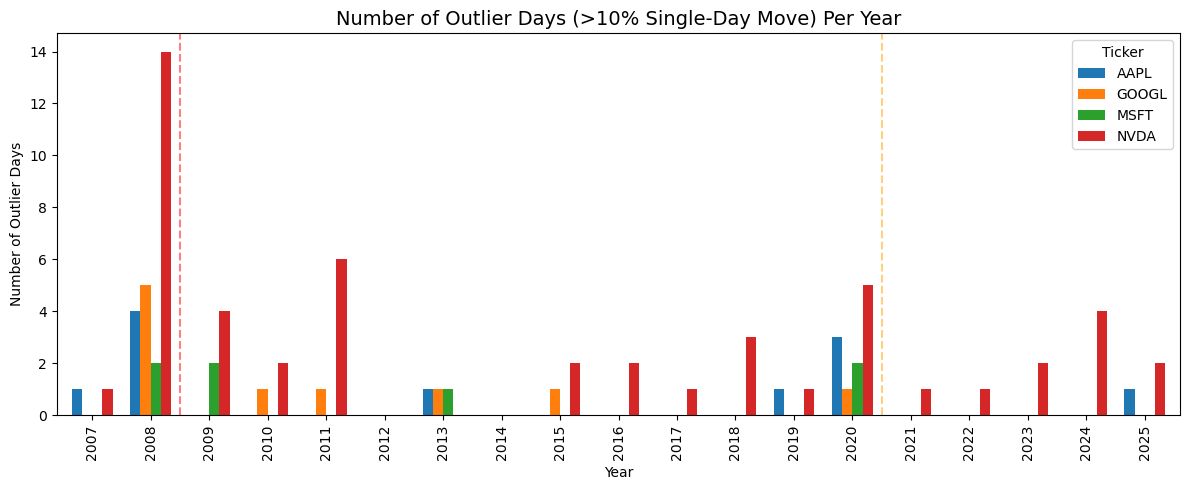

,AAPL,GOOGL,MSFT,NVDA,Count
Date,,,,,
2008,4,5,2,14,25
2020,3,1,2,5,11
2011,0,1,0,6,7
2009,0,0,2,4,6
2024,0,0,0,4,4
2025,1,0,0,2,3
2010,0,1,0,2,3
2013,1,1,1,0,3
2015,0,1,0,2,3


In [13]:
outlier_counts = tsf_data['Outlier'].copy()
outlier_counts.index = tsf_data.index.year # we want to count the outliers per year
yearly_outliers = outlier_counts.groupby(level = 0).sum() #grouping by the year

#lets make the actual plot now that we have our yearly_outliers
fig, ax = plt.subplots(figsize = (12,5))
yearly_outliers.plot(kind = 'bar', ax = ax, width = 0.7)

ax.set_title('Number of Outlier Days (>10% Single-Day Move) Per Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Outlier Days')
ax.legend(title='Ticker')
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.5, label='2008 Crisis')
ax.axvline(x=13.5, color='orange', linestyle='--', alpha=0.5, label='COVID')
plt.tight_layout()
plt.show()

#lets also show the rankings for which years had the most outliers within the dataset
year_out_c = yearly_outliers.copy()
year_out_c["Count"] = yearly_outliers.sum(axis = 1)
ranked_yearly_outliers = year_out_c.sort_values(by = 'Count', ascending = False)
display(ranked_yearly_outliers)

***Key Takeaways***
1. 2008 and 2020 recorded the most outliers within the dataframe. This makes sense because of the 2008 Financial Crisis
   and the COVID-19 epidemic that took place in 2020
2. 2012 and 2014 both recorded 0 outliers, showing that in both years, stock prices for these companies had low volatility
3. NVDA accounts for a majority of the outliers within the dataframe across all the years, reflecting that it had much higher volatility
   compared to AAPL, GOOGL, and MSFT, which behaved relatively stably even during the crisis periods, compared to NVDA
4. The re-emergence of NVDA outliers in 2023–2025 (2 in 2023, 4 in 2024, 2 in 2025) coincides with the AI boom, suggesting a new
   volatility regime driven by earnings surprises and rapid sentiment shifts around AI demand.
5. NVDA's outliers appear consistently from 2007 through 2025, while the other three stocks' outliers are almost entirely concentrated in
   2008 and 2020, suggesting NVDA's volatility is stock-specific rather than purely macro-driven.

#### Visualization 2: Price and Returns Over Time
* This visualizations will plot the noramlized closing prices of AAPL, GOOGL, MSFT, and NVDA
  over the years in this dataframe
* The closing prices are rebased to 100 at the start to allow fair comparison across different
  price levels
* A second panel will show the daily log returns for each ticker, highlighting periods of
  extreme volatility
* Shaded regions will mark the 2008 Financial Crisis and the COVID-19 crash in 2020
* We use log returns to normalize the scale differences and better capture the true magnitude of
  daily moves

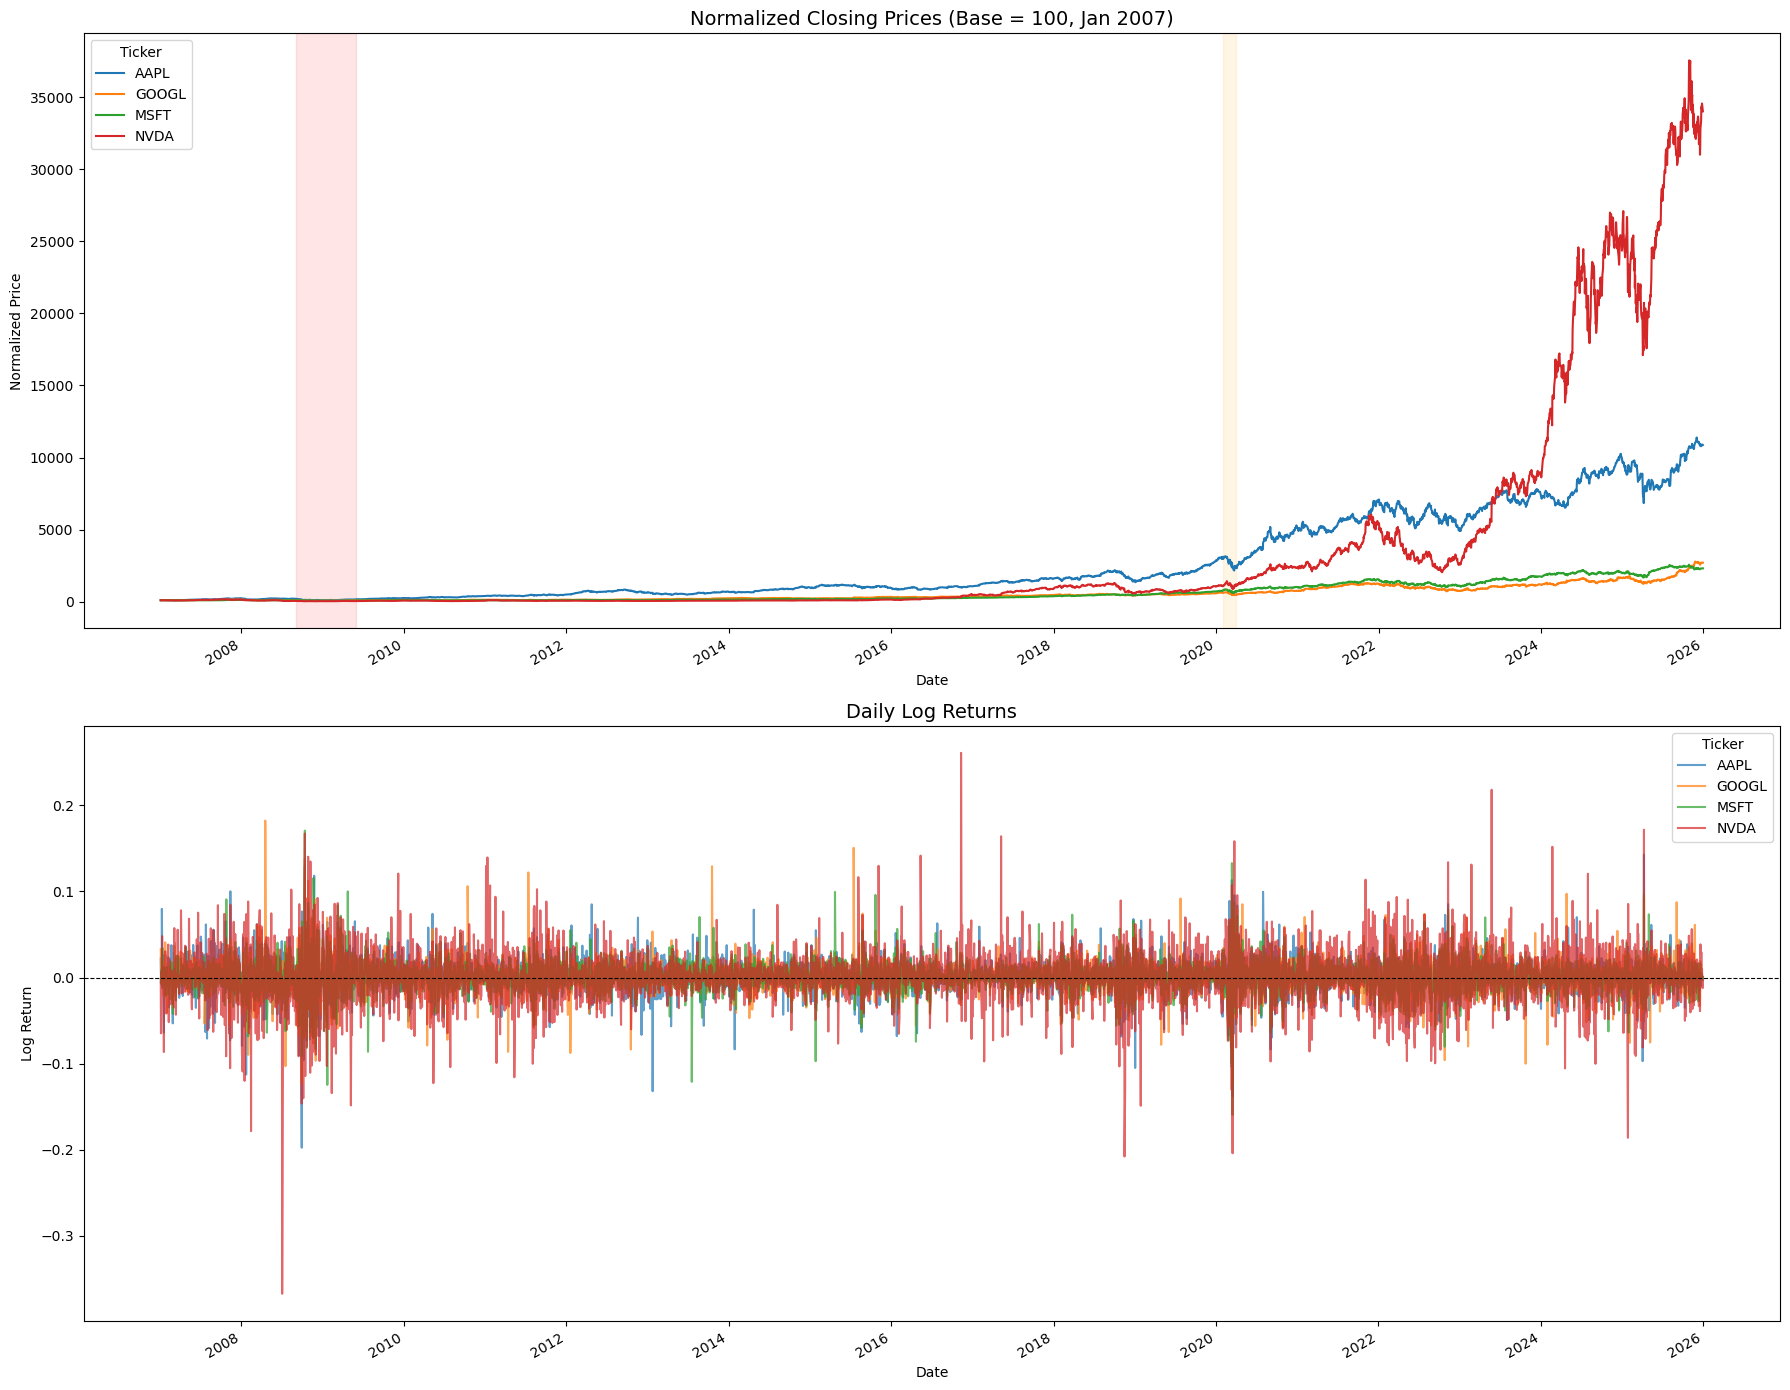

In [14]:
# Normalize prices to 100 at start
normalized = tsf_data['Close'] / tsf_data['Close'].iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Plot 1: Normalized Prices
normalized.plot(ax=axes[0])
axes[0].set_title('Normalized Closing Prices (Base = 100, Jan 2007)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Normalized Price')
axes[0].legend(title='Ticker')
axes[0].axvspan('2008-09-01', '2009-06-01', color='red', alpha=0.1, label='2008 Crisis') # this will represent the 2008 financial crisis
axes[0].axvspan('2020-02-01', '2020-04-01', color='orange', alpha=0.1, label='COVID') # this will represent the 2020 Covid-19 Crash

# Plot 2: Log Returns
log_returns.plot(ax=axes[1], alpha=0.7)
axes[1].set_title('Daily Log Returns', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
axes[1].legend(title='Ticker')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

***Key Takeaways***
* Interestingly enough, the biggest spike was from NVDA from around 2023 to the end of our dataset time range, signaling that the AI boom had a huge effect on NVDA's stock price (This would make sense because we all know how heavily Nvidia is involved with this AI-race)
* The largest log return value (in terms of magnitude) was once again NVDA, with a single day drop of about 30%+, hinting at how severely the financial crisis impacted semiconducter stocks compared to software and consumer tech companies
* AAPL, GOOGL, and MSFT show remarkably similar normalized growth trajectories, suggesting strong co-movement among large-cap tech stocks. NVDA, however, completely decouples from the group starting around 2022–2023, driven by GPU demand from AI and data center workloads.
* The log returns chart shows clear volatility clustering, i.e., periods of high volatility (2008, 2020) are followed by more high volatility, and calm periods cluster together. This is a hallmark of financial time-series data and motivates the use of time-series specific models like ARIMA in the modeling section.

#### Visualization 3: 30-Day Rolling Volatility
* The next plot we're making is a rolling volatility graph to show how risk changes over time
* We will plot the rolling standard deviation of log returns for each ticker
* We will use np.sqrt(252) to anualize the rolling volatility since there are 252 trading days in a year

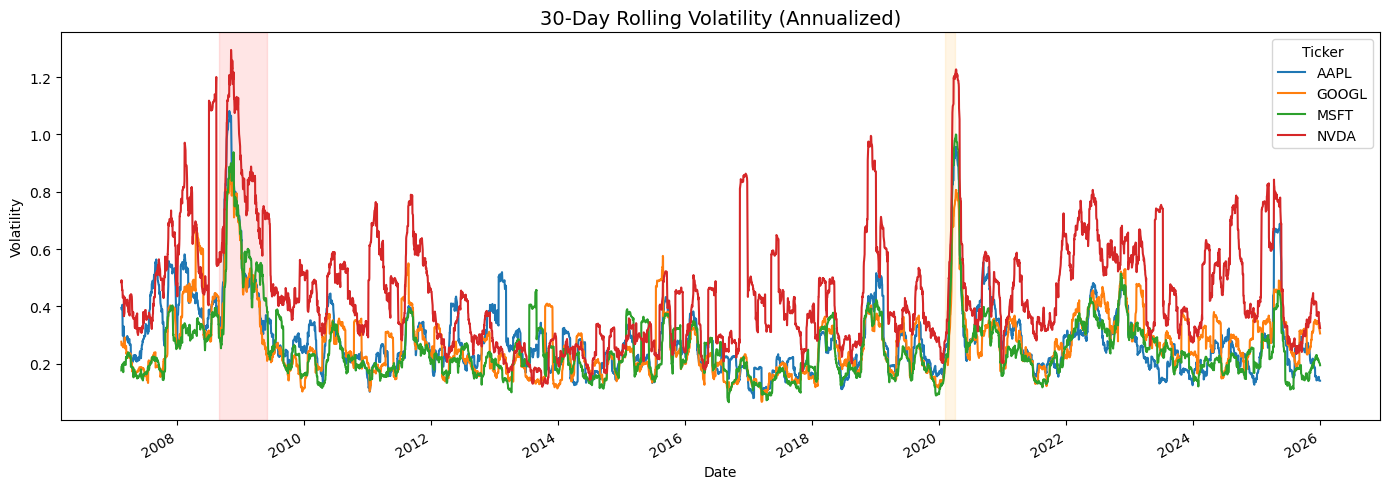

In [15]:
# 30-day rolling volatility
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol.plot(ax=ax)
ax.set_title('30-Day Rolling Volatility (Annualized)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend(title='Ticker')
ax.axvspan('2008-09-01', '2009-06-01', color='red', alpha=0.1)
ax.axvspan('2020-02-01', '2020-04-01', color='orange', alpha=0.1)
plt.tight_layout()
plt.show()

***Key Takeaways***
* NVDA consistently sits above all other tickers in volatility throughout the entire 18-year period, confirming it carries significantly more risk than AAPL, GOOGL, and MSFT at virtually every point in time.
* All four stocks spike simultaneously during the 2008 financial crisis and the 2020 COVID crash, confirming that systemic market shocks drive correlated volatility across the entire tech sector regardless of individual stock characteristics.
* AAPL, GOOGL, and MSFT show a clear pattern of volatility mean reversion, i.e., after each spike they return to their baseline levels relatively quickly. NVDA however remains structurally elevated, rarely dropping to the calm levels the other three enjoy.
* The 2008 crisis produced the highest volatility spike in the dataset, with NVDA briefly exceeding 1.2 (equivalent to 120% annualized swings), dwarfing even the COVID spike in 2020, suggesting the financial crisis was a more sustained shock to semiconductor stocks than the pandemic was.
* Post-2020, all four stocks show noticeably higher baseline volatility compared to the 2012–2016 period, suggesting the market has entered a structurally more volatile regime, likely driven by interest rate uncertainty and AI-driven sentiment swings.

#### Visualization 4: Correlation Heatmap between NVDA, AAPL, GOOGL, and MSFT
* The last plot before our modeling will be a heatmap to represent how correlated each of the companies' log return trends is with the others
* We'll use seaborn for this plot because we want to use a heatmap

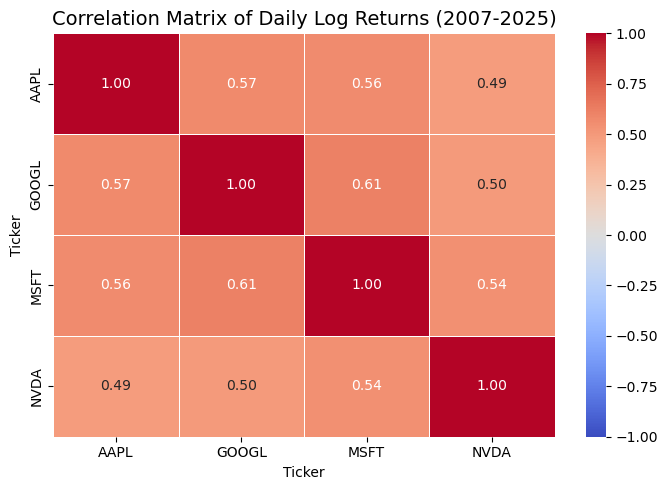

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = log_returns.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation Matrix of Daily Log Returns (2007-2025)', fontsize=14)
plt.tight_layout()
plt.show()

***Key Takeaways***
* All four stocks show moderate positive correlations with each other (ranging from 0.49 to 0.61), confirming they move in the same general direction as part of the broader tech sector, but none are strongly correlated enough to be considered redundant in a portfolio.
* NVDA has the lowest correlation with every other ticker (0.49–0.54), consistent with what we observed in the normalized price chart: its returns are more idiosyncratic and driven by factors specific to the semiconductor/AI industry rather than broad tech sentiment.
* GOOGL and MSFT are the most correlated pair at 0.61, which makes intuitive sense as both are enterprise-focused cloud and software companies with overlapping revenue drivers.
* The absence of any near-zero or negative correlations suggests that in a downturn, all four stocks would likely fall together (theres no natural hedge)

## Part 2: Model Building Comparison, and Insights

In [ ]:
# lets import all of the libraries that we'll need

#ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller #tests for a null hypothesis that our data is non stationary
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
"""
ACF: correlation of times series with its lags an
PACF: partial correlation of times series with its lags after removing the effects of lower-order lags between them
"""
#LSTM (I'm more familiar with pytrorch than tensorflow)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# N-HiTS
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE
from utilsforecast.plotting import plot_series


#### Model 1: ARIMA
* We'll use this model as a baseline

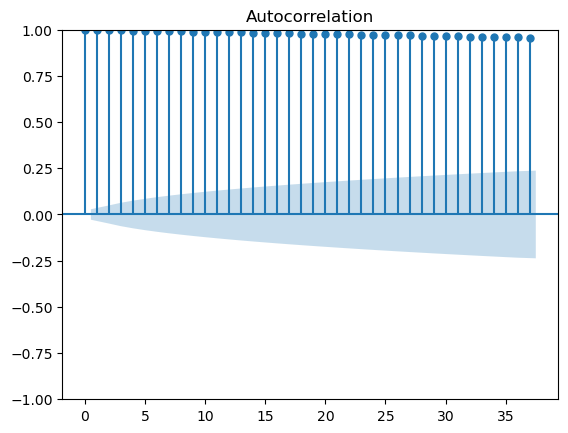

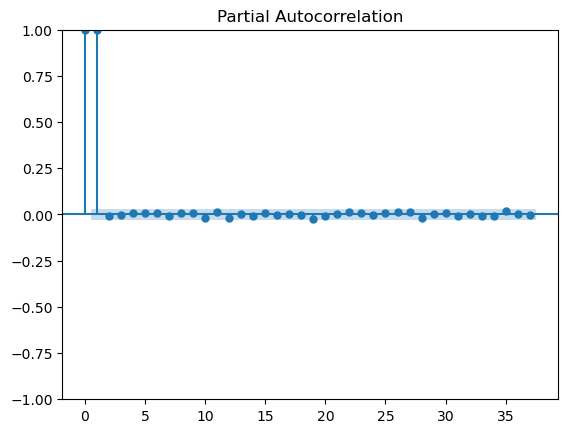

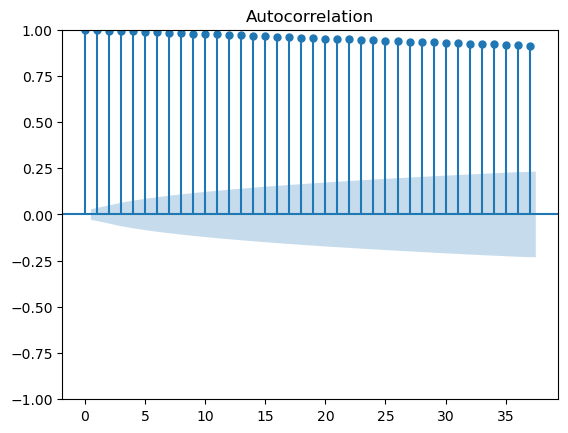

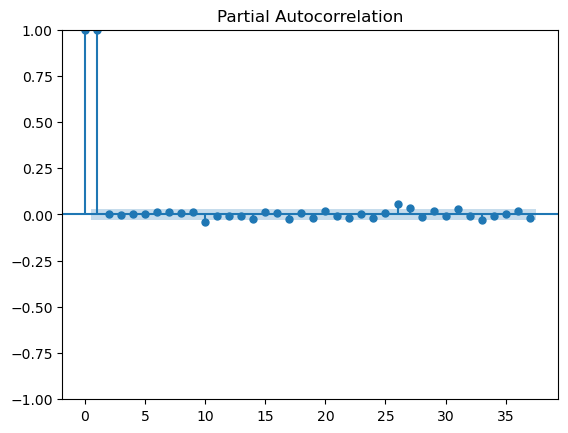

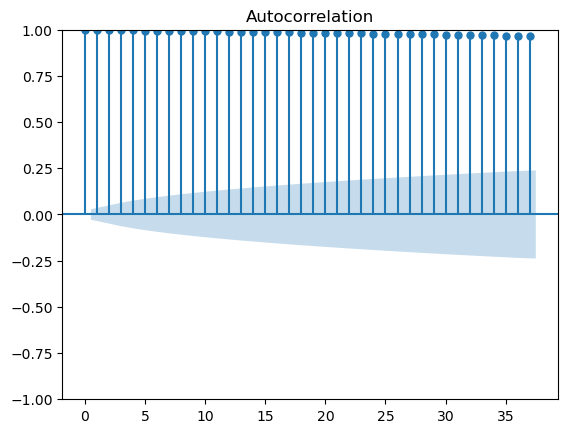

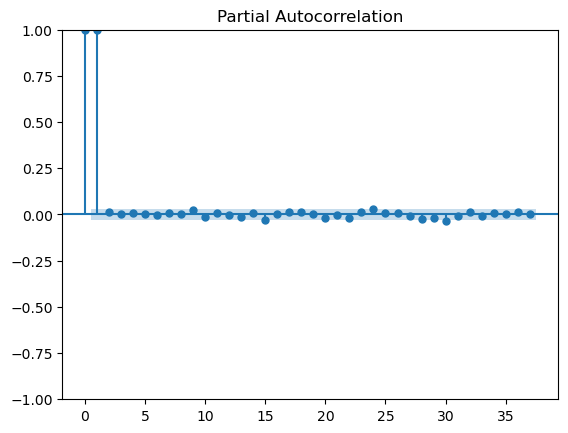

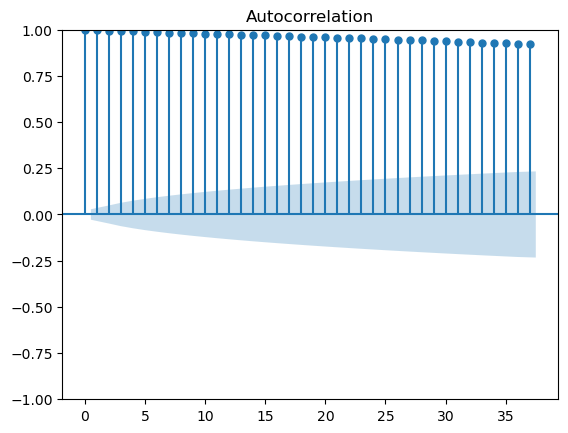

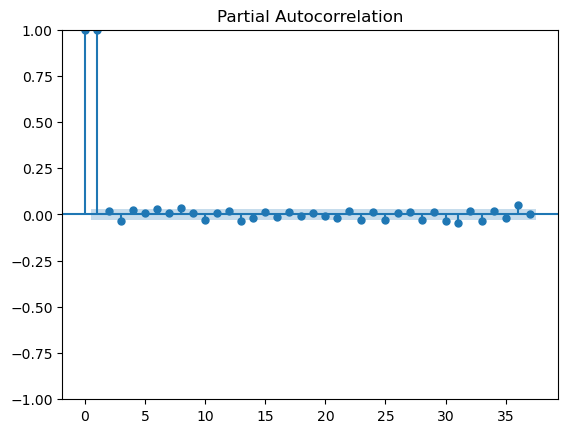

In [18]:
#step 1: make the Close variable stationary

arima_tsf = tsf_data.copy()

acf_plots = {}
pacf_plots = {}
tickers = ['AAPL', 'GOOGL', "MSFT", "NVDA"]

for tick in tickers:
    series = arima_tsf["Close"][tick]
    acf_plots[tick] = plot_acf(series)
    pacf_plots[tick] = plot_pacf(series)
    

* all of our plots show that for acf, each leg is highly correlated with the last leg, and that theres a spike of correlation between the first leg and then a drop off in partial correlation from there
* these are indicators of non-stationary data

In [19]:
for tick in tickers:
    series = arima_tsf["Close"][tick]
    print(f'{tick} p-val: {adfuller(series)[1]:.4f}')

AAPL p-val: 0.9983
GOOGL p-val: 1.0000
MSFT p-val: 0.9981
NVDA p-val: 0.9990


* all of our models have very high p values --> fail to reject null hypothesis that our data is not stationary

In [20]:
#to actually transform our data, lets use the log returns
arima_data = {}
for tick in tickers:
    series = np.log(tsf_data['Close'][tick] / tsf_data['Close'][tick].shift(1)).dropna()
    series.index = pd.DatetimeIndex(series.index)
    series = series.asfreq('B', fill_value=0)
    arima_data[tick] = series
    result = adfuller(arima_data[tick])
    print(f'{tick} ADF Statistic: {result[0]:.4f}, p-value: {result[1]}') #the more negative the statistic, the more starionary

AAPL ADF Statistic: -16.3478, p-value: 2.952587424004603e-29
GOOGL ADF Statistic: -22.6771, p-value: 0.0
MSFT ADF Statistic: -17.0715, p-value: 7.819249729194694e-30
NVDA ADF Statistic: -73.4145, p-value: 0.0


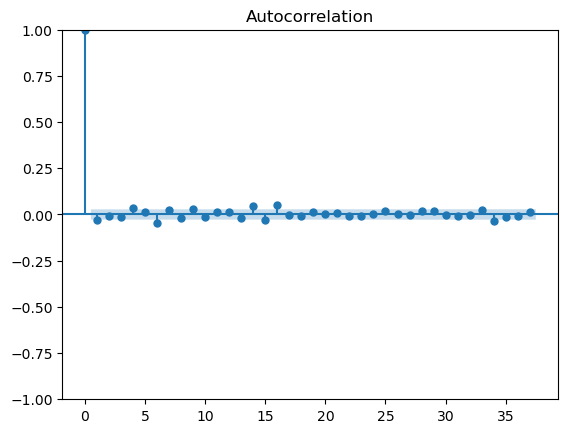

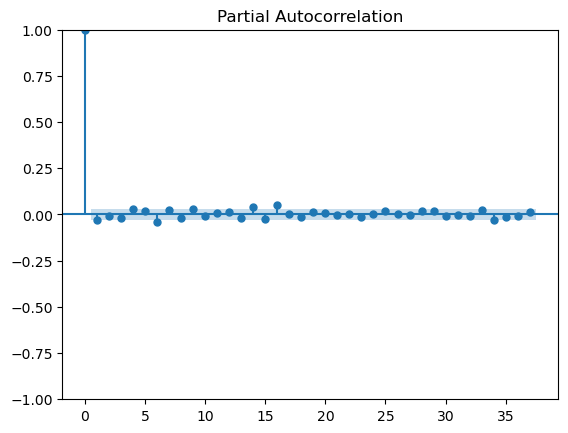

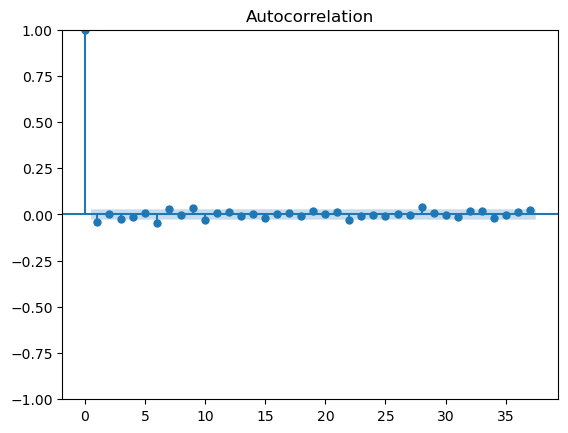

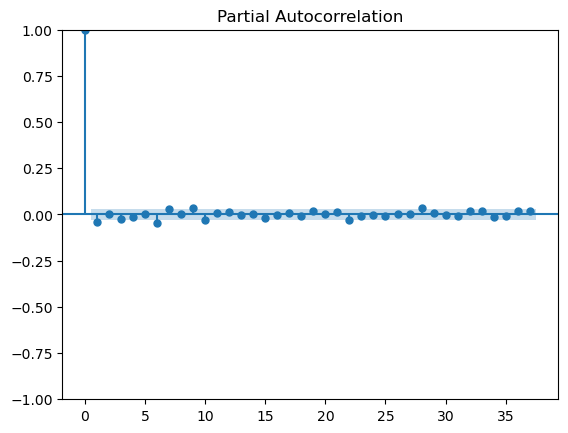

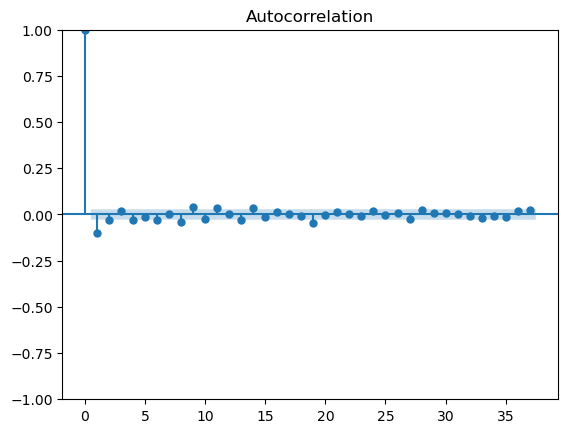

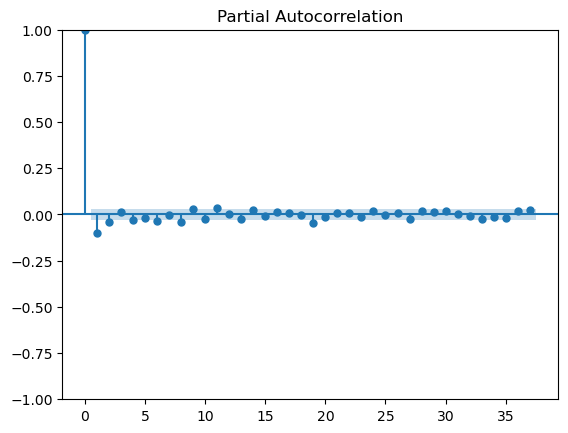

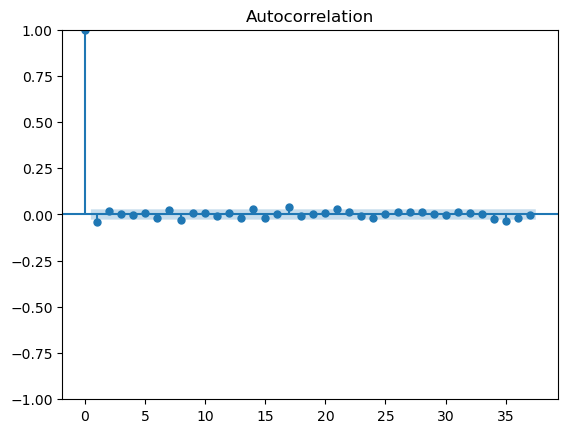

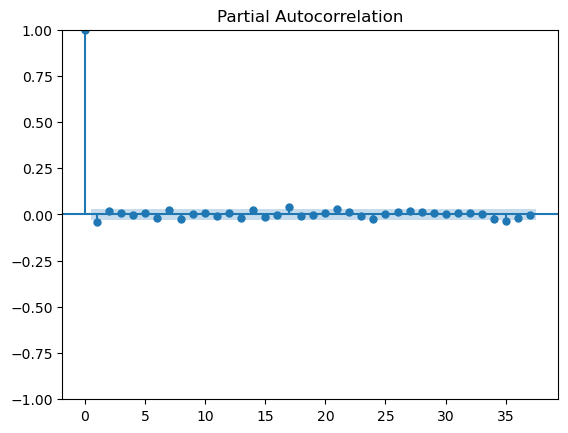

In [21]:
stat_acf_plots = {}
stat_pacf_plots = {}
for tick in tickers:
    series = arima_data[tick]
    stat_acf_plots[tick] = plot_acf(series)
    stat_pacf_plots[tick] = plot_pacf(series)

* Because for each ticker plot, there's a significant spike at lag q (for acf) and p (for pacf), we'll use an ARIMA(p,d,q) model
* If we had only seen a significant spike at lag p for pacf but a gradual decay for acf, we would use an ARIMA(p,d,0) model
* Likewise, if we had seen only a significant at lag q for acf but a gradual decay for pacf, we would use an ARIMA(0,d,q) model

In [22]:
#lets do our train_test_splits
# 80/20 train test split
split = int(len(arima_data['AAPL']) * 0.8) # keep it as 80% of the data, we don't want to overfit

arima_train = {tick: arima_data[tick][:split] for tick in tickers}
arima_test = {tick:arima_data[tick][split:split+200] for tick in tickers} #test on the next 200 days (stays consistent for all the models)

print(f'Train size: {split}, Test size: 200')

Train size: 3963, Test size: 200


In [23]:
#step 2: Fitting the ARIMA Model
arima_models = {}
arima_results = {}

for tick in tickers:
    model = ARIMA(arima_train[tick], order=(1, 1, 1)) #using 1,1,1 because both the acf and pacf plots spiked at the first lags --> (p=1 (pacf), d=1 (is stationary), q=1 (acf) 
    result = model.fit(method_kwargs={"maxiter": 1000})
    arima_models[tick] = model
    arima_results[tick] = result
    print(f'{tick} AIC: {result.aic:.4f}, BIC: {result.bic:.4f}')

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AAPL AIC: -19785.1788, BIC: -19766.3252
GOOGL AIC: -20623.8271, BIC: -20604.9735
MSFT AIC: -20911.7467, BIC: -20892.8932
NVDA AIC: -16556.5045, BIC: -16537.6510


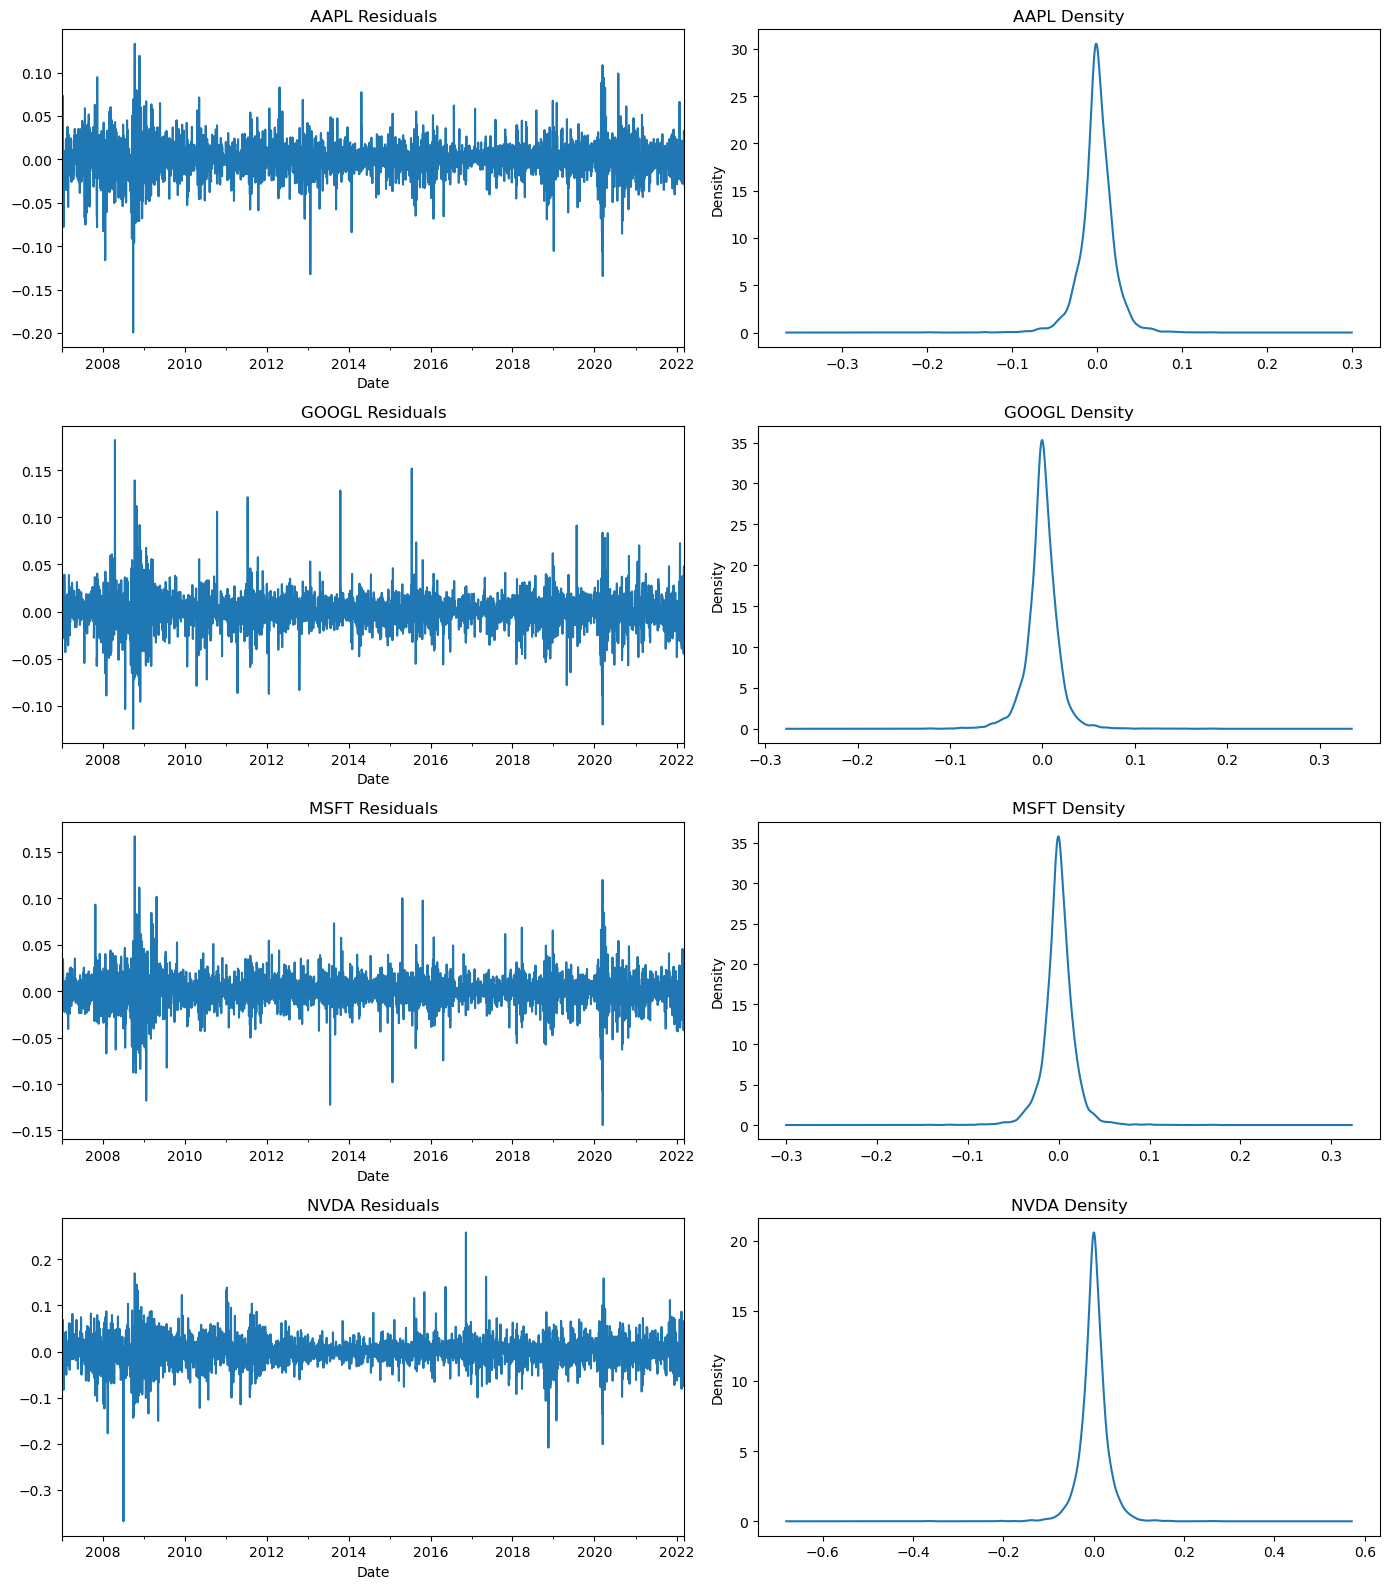

In [24]:
#step 3: Making predictions
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for i, tick in enumerate(tickers):
    residuals = pd.Series(arima_results[tick].resid[1:])
    residuals.plot(title=f'{tick} Residuals', ax=axes[i][0])
    residuals.plot(title=f'{tick} Density', kind='kde', ax=axes[i][1])

plt.tight_layout()
plt.show()

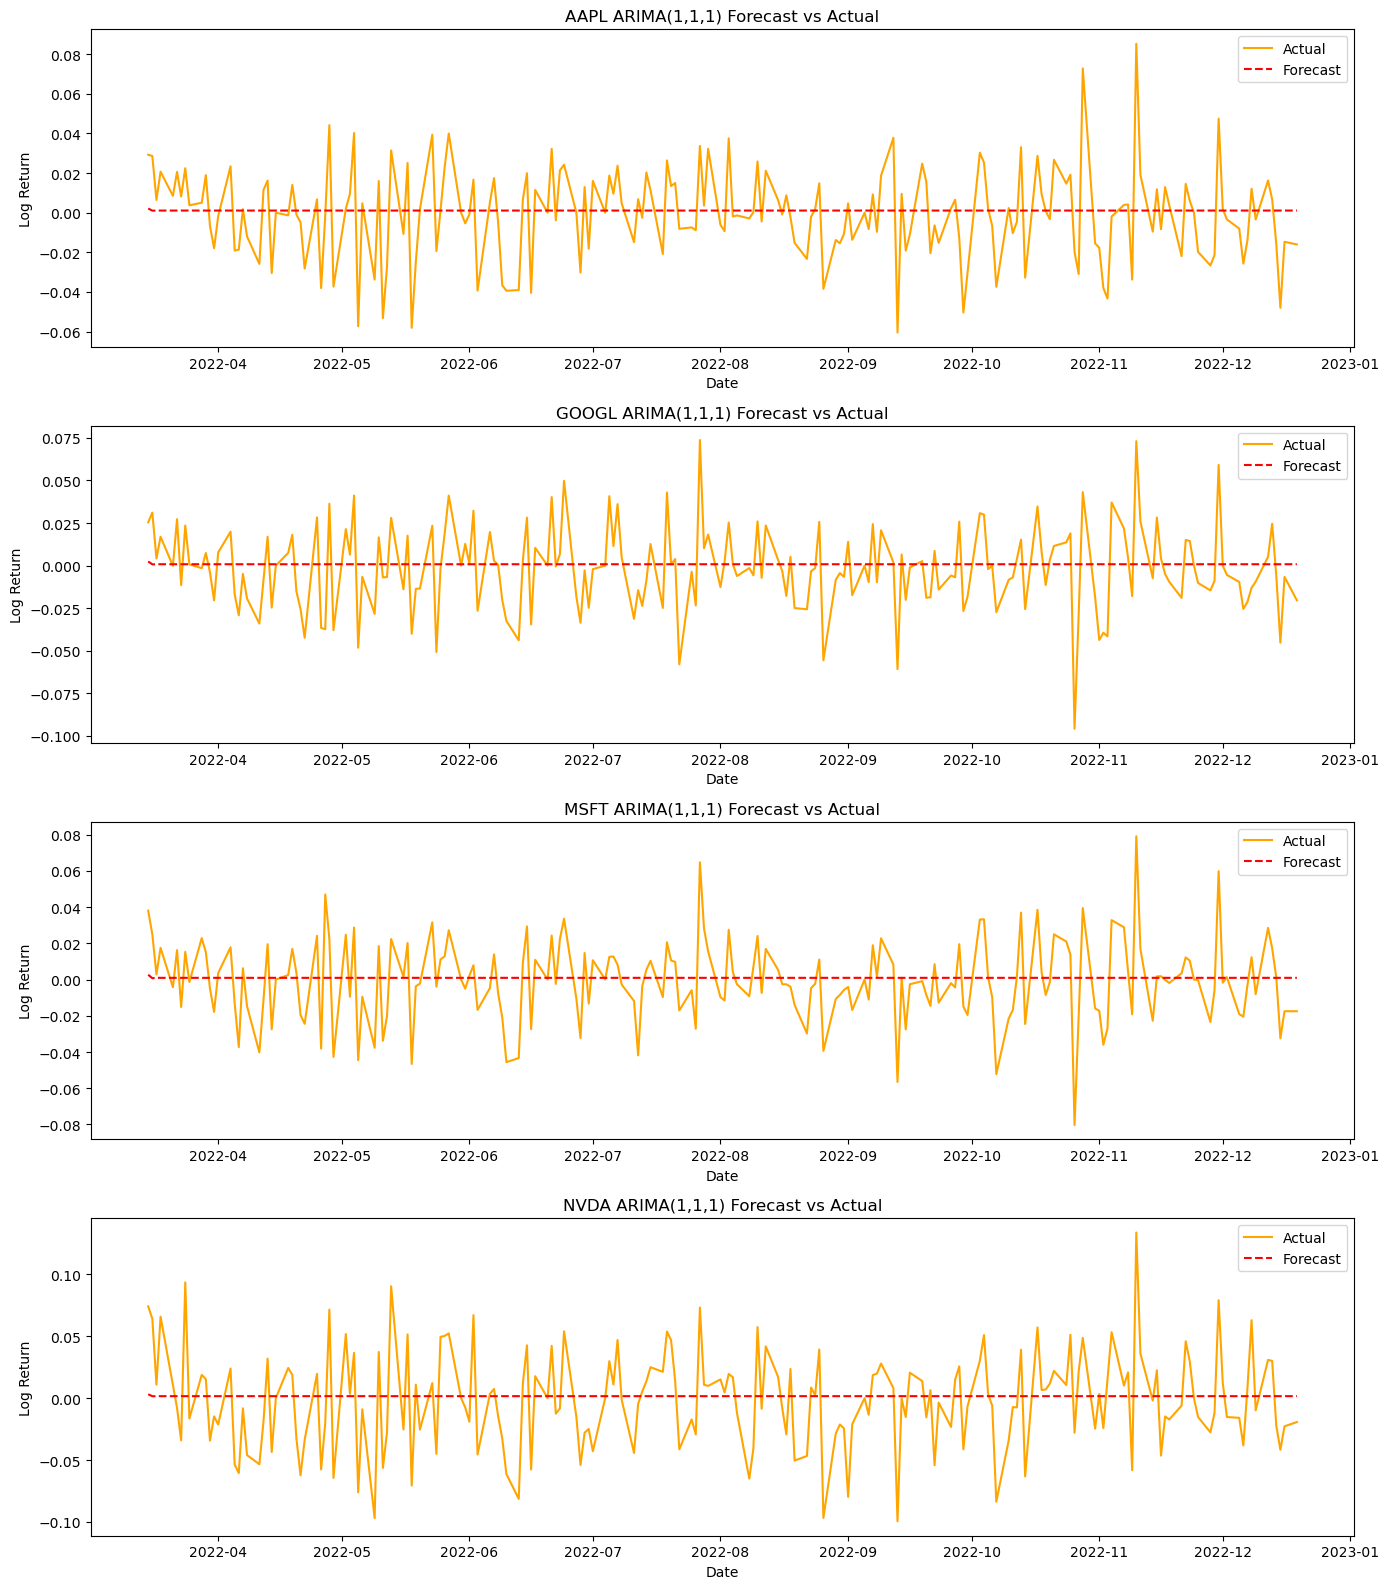

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, tick in enumerate(tickers):
    forecast = arima_results[tick].forecast(steps=len(arima_test[tick]))
    
    axes[i].plot(arima_test[tick].index, arima_test[tick], label='Actual', color='orange')
    axes[i].plot(arima_test[tick].index, forecast, label='Forecast', color='red', linestyle='--')
    axes[i].set_title(f'{tick} ARIMA(1,1,1) Forecast vs Actual')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Return')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [26]:
#step 4: Evaluation Metrics
arima_metrics = {}

for tick in tickers:
    forecast_log = arima_results[tick].forecast(steps=len(arima_test[tick]))
    
    rmse = np.sqrt(mean_squared_error(arima_test[tick], forecast_log))
    mae = mean_absolute_error(arima_test[tick], forecast_log)
    
    arima_metrics[tick] = {'RMSE': rmse, 'MAE': mae}
    print(f'ARIMA - {tick} -> RMSE: {rmse:.6f}, MAE: {mae:.6f}')

ARIMA - AAPL -> RMSE: 0.022981, MAE: 0.017505
ARIMA - GOOGL -> RMSE: 0.024653, MAE: 0.018801
ARIMA - MSFT -> RMSE: 0.022439, MAE: 0.017015
ARIMA - NVDA -> RMSE: 0.039297, MAE: 0.031005


***ARIMA(1,1,1) Results & Diagnostics***

**Model Selection**
- ARIMA(1,1,1) was selected based on ACF/PACF analysis of log returns, which showed significant spikes at lag 1 for all four tickers before cutting off
- d=1 was confirmed via the ADF test — all raw price series were non-stationary (p > 0.05) but became stationary after log differencing

**AIC/BIC Results**
- MSFT achieved the best fit (AIC: -20,912), followed by GOOGL (-20,624), AAPL (-19,785), and NVDA (-16,557)
- NVDA's relatively poor AIC reflects its higher idiosyncratic volatility, making it the hardest stock to model within a linear framework

**Forecast Results**
- As expected under the Efficient Market Hypothesis, ARIMA(1,1,1) converges to a near-zero flat forecast for all tickers — daily log returns have minimal exploitable linear autocorrelation
- MSFT produced the lowest error (RMSE: 0.022439, MAE: 0.017015), while NVDA was the hardest to forecast (RMSE: 0.039297, MAE: 0.031005)
- AAPL and GOOGL fell in between with comparable error magnitudes

**Residual Diagnostics**
- Residuals are centered around zero with no obvious trend for all tickers, suggesting ARIMA captured whatever linear structure existed in the data
- Density plots show leptokurtic (fat-tailed) distributions across all tickers — particularly NVDA — meaning extreme return events occur far more frequently than a normal distribution predicts
- This fat-tailed behavior is a core limitation of ARIMA and motivates the use of LSTM and N-HiTS, which can capture nonlinear and regime-dependent dynamics

#### Model 2: LSTM (with PyTorch)
* This will be our first deep learning approach for forecasting close values based on our training OHLCV from yfinance
* We expect an improvement of forecasting compared to the previous ARIMA model

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device

device(type='cpu')

In [28]:
from copy import deepcopy as dc

def preparing_lstm_df(df, n_steps, ticker): #defining a function that basically just builds our lstm dataframes using log returns
    data = pd.DataFrame()
    data['Close'] = np.log(dc(df['Close'][ticker]) / dc(df['Close'][ticker]).shift(1))
    data.dropna(inplace=True)
    data.index = data.index
    
    for i in range(1, n_steps + 1):
        data[f'Close(t-{i})'] = data['Close'].shift(i)
    
    data.dropna(inplace=True)
    return data

n_steps = 7
lstm_data = {}
for tick in tickers:
    lstm_data[tick] = preparing_lstm_df(tsf_data, n_steps, tick)
    print(f'                                           {tick} Data:\n')
    display(lstm_data[tick].head())

                                           AAPL Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-16,0.025872,-0.012394,-0.012449,0.046746,0.079800,0.004926,-0.007146,0.021953
2007-01-17,-0.022391,0.025872,-0.012394,-0.012449,0.046746,0.079800,0.004926,-0.007146
2007-01-18,-0.063928,-0.022391,0.025872,-0.012394,-0.012449,0.046746,0.079800,0.004926
2007-01-19,-0.006420,-0.063928,-0.022391,0.025872,-0.012394,-0.012449,0.046746,0.079800
2007-01-22,-0.019511,-0.006420,-0.063928,-0.022391,0.025872,-0.012394,-0.012449,0.046746


                                           GOOGL Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-16,-0.001427,0.010510,0.020745,0.008123,0.003963,-0.007437,0.008099,0.032963
2007-01-17,-0.013979,-0.001427,0.010510,0.020745,0.008123,0.003963,-0.007437,0.008099
2007-01-18,-0.019186,-0.013979,-0.001427,0.010510,0.020745,0.008123,0.003963,-0.007437
2007-01-19,0.003928,-0.019186,-0.013979,-0.001427,0.010510,0.020745,0.008123,0.003963
2007-01-22,-0.018361,0.003928,-0.019186,-0.013979,-0.001427,0.010510,0.020745,0.008123


                                           MSFT Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-16,-0.001603,0.016476,0.034464,-0.010064,0.001002,0.009737,-0.005719,-0.001676
2007-01-17,-0.001927,-0.001603,0.016476,0.034464,-0.010064,0.001002,0.009737,-0.005719
2007-01-18,-0.003221,-0.001927,-0.001603,0.016476,0.034464,-0.010064,0.001002,0.009737
2007-01-19,0.003542,-0.003221,-0.001927,-0.001603,0.016476,0.034464,-0.010064,0.001002
2007-01-22,-0.012616,0.003542,-0.003221,-0.001927,-0.001603,0.016476,0.034464,-0.010064


                                           NVDA Data:



,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
2007-01-16,0.001702,0.013432,-0.003733,0.048145,-0.019655,0.007401,-0.064705,-0.004723
2007-01-17,-0.021194,0.001702,0.013432,-0.003733,0.048145,-0.019655,0.007401,-0.064705
2007-01-18,-0.086405,-0.021194,0.001702,0.013432,-0.003733,0.048145,-0.019655,0.007401
2007-01-19,0.005976,-0.086405,-0.021194,0.001702,0.013432,-0.003733,0.048145,-0.019655
2007-01-22,0.000000,0.005976,-0.086405,-0.021194,0.001702,0.013432,-0.003733,0.048145


In [29]:
train_lstms = {tick : lstm_data[tick][:split] for tick in tickers}
test_lstms = {tick : lstm_data[tick][split:split+200] for tick in tickers}

# now lets use a MinMaxScaler to scale our data between 0 and 1 to make it easier for our model to train our vals
scalers = {}
lstm_train_scaled = {}
lstm_test_scaled = {}

for tick in tickers:
    scalers[tick] = MinMaxScaler(feature_range = (-1,1))
    lstm_train_scaled[tick] = scalers[tick].fit_transform(train_lstms[tick].to_numpy())
    lstm_test_scaled[tick] = scalers[tick].transform(test_lstms[tick].to_numpy())

X_train_vals = {tick : lstm_train_scaled[tick][:, 1:] for tick in tickers}
y_train_vals = {tick : lstm_train_scaled[tick][:, 0] for tick in tickers}
X_test_vals = {tick: lstm_test_scaled[tick][:, 1:] for tick in tickers}
y_test_vals = {tick: lstm_test_scaled[tick][:, 0] for tick in tickers}

X_train_vals = {tick: X_train_vals[tick].reshape(X_train_vals[tick].shape[0], X_train_vals[tick].shape[1], 1) for tick in tickers}
X_test_vals = {tick: X_test_vals[tick].reshape(X_test_vals[tick].shape[0], X_test_vals[tick].shape[1], 1) for tick in tickers}
for tick in tickers: 
    print(X_train_vals[tick].shape, y_train_vals[tick].shape)
    print(X_test_vals[tick].shape, y_test_vals[tick].shape)
    print()

(3963, 7, 1) (3963,)
(200, 7, 1) (200,)

(3963, 7, 1) (3963,)
(200, 7, 1) (200,)

(3963, 7, 1) (3963,)
(200, 7, 1) (200,)

(3963, 7, 1) (3963,)
(200, 7, 1) (200,)



In [30]:
#now lets build the actual neural network

#step 1: Convert our data to tensors (neural networks take in tensors as inputs)
X_train_tensors = {tick: torch.tensor(X_train_vals[tick], dtype = torch.float32) for tick in tickers}
X_test_tensors = {tick: torch.tensor(X_test_vals[tick], dtype = torch.float32) for tick in tickers}
y_train_tensors = {tick: torch.tensor(y_train_vals[tick], dtype = torch.float32) for tick in tickers}

train_dataframes = {tick : TensorDataset(X_train_tensors[tick], y_train_tensors[tick]) for tick in tickers}
train_loaders = {tick: DataLoader(train_dataframes[tick], batch_size = 32, shuffle = False) for tick in tickers}



In [31]:
#Step 2: Define the LSTM Model using PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size = 1, hidden1 = 64, hidden2 = 32, output_size = 1):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first = True)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.fc = nn.Linear(hidden2, output_size)
    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        out = self.fc(out[:, -1, :])
        return out
lstm_models = {tick: LSTMModel().to(device) for tick in tickers}
#Step 3: define our loss function and our optimizer
criterion = nn.L1Loss() # this is MAE in PyTorch
optimizers = {tick: torch.optim.Adam(lstm_models[tick].parameters()) for tick in tickers}


In [32]:
#step 4: train with early stopping
patience = 50
best_losses = {}
n_epochs = 300 #pass through 300 times unless our loss isn't decreasing for 30 steps before we reach 300

for tick in tickers:
    
    print(f'\nTraining LSTM for {tick}...')
    
    best_loss = float('inf')
    patience_cnt = 0
    torch.manual_seed(42)
    np.random.seed(42)
    best_weights = {k: v.clone() for k, v in lstm_models[tick].state_dict().items()} # init with starting weights

    
    for epoch in range(n_epochs):
        
        lstm_models[tick].train()
        train_loss = 0
        
        for X_batch, y_batch in train_loaders[tick]:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizers[tick].zero_grad()
            preds = lstm_models[tick](X_batch).squeeze()
            loss = criterion(preds, y_batch.squeeze())
            loss.backward()
            optimizers[tick].step()
            train_loss += loss.item()
        
        train_loss /= len(train_loaders[tick])
        
        if train_loss < best_loss:
            best_loss = train_loss
            patience_cnt = 0
            best_weights = {k: v.clone() for k, v in lstm_models[tick].state_dict().items()} #tells us the best weights at the end of our training process
        else: #check 35 steps to see if the loss decreases this at all
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1} | Loss: {train_loss:.6f}')
    best_losses[tick] = best_loss 
    lstm_models[tick].load_state_dict(best_weights)
    print(f'{tick} training complete, best loss: {best_loss:.6f}')
    


Training LSTM for AAPL...
Epoch 10 | Loss: 0.086670
Epoch 20 | Loss: 0.086588
Epoch 30 | Loss: 0.086492
Epoch 40 | Loss: 0.086473
Epoch 50 | Loss: 0.086387
Epoch 60 | Loss: 0.086250
Epoch 70 | Loss: 0.086231
Epoch 80 | Loss: 0.085902
Epoch 90 | Loss: 0.085636
Epoch 100 | Loss: 0.085458
Epoch 110 | Loss: 0.085087
Epoch 120 | Loss: 0.084912
Epoch 130 | Loss: 0.084973
Epoch 140 | Loss: 0.084177
Epoch 150 | Loss: 0.083703
Epoch 160 | Loss: 0.083345
Epoch 170 | Loss: 0.083157
Epoch 180 | Loss: 0.082614
Epoch 190 | Loss: 0.082475
Epoch 200 | Loss: 0.081981
Epoch 210 | Loss: 0.081825
Epoch 220 | Loss: 0.081103
Epoch 230 | Loss: 0.080498
Epoch 240 | Loss: 0.080247
Epoch 250 | Loss: 0.079687
Epoch 260 | Loss: 0.078647
Epoch 270 | Loss: 0.078057
Epoch 280 | Loss: 0.076866
Epoch 290 | Loss: 0.075757
Epoch 300 | Loss: 0.074205
AAPL training complete, best loss: 0.074205

Training LSTM for GOOGL...
Epoch 10 | Loss: 0.081375
Epoch 20 | Loss: 0.081260
Epoch 30 | Loss: 0.081231
Epoch 40 | Loss: 0.081

In [33]:
#step 5: preditct and inverse transforming our data
lstm_predictions = {}
y_test_actual = {}

for tick in tickers:
    lstm_models[tick].eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test_vals[tick], dtype=torch.float32).to(device)
        y_pred_scaled = lstm_models[tick](X_test_t).cpu().numpy()
    
    # Inverse transform predictions and actual values
    dummy_pred = np.zeros((len(y_pred_scaled), lstm_train_scaled[tick].shape[1]))
    dummy_test = np.zeros((len(y_test_vals[tick]), lstm_train_scaled[tick].shape[1]))
    
    dummy_pred[:, 0] = y_pred_scaled.squeeze()
    dummy_test[:, 0] = y_test_vals[tick]
    
    lstm_predictions[tick] = scalers[tick].inverse_transform(dummy_pred)[:, 0]
    y_test_actual[tick] = scalers[tick].inverse_transform(dummy_test)[:, 0]

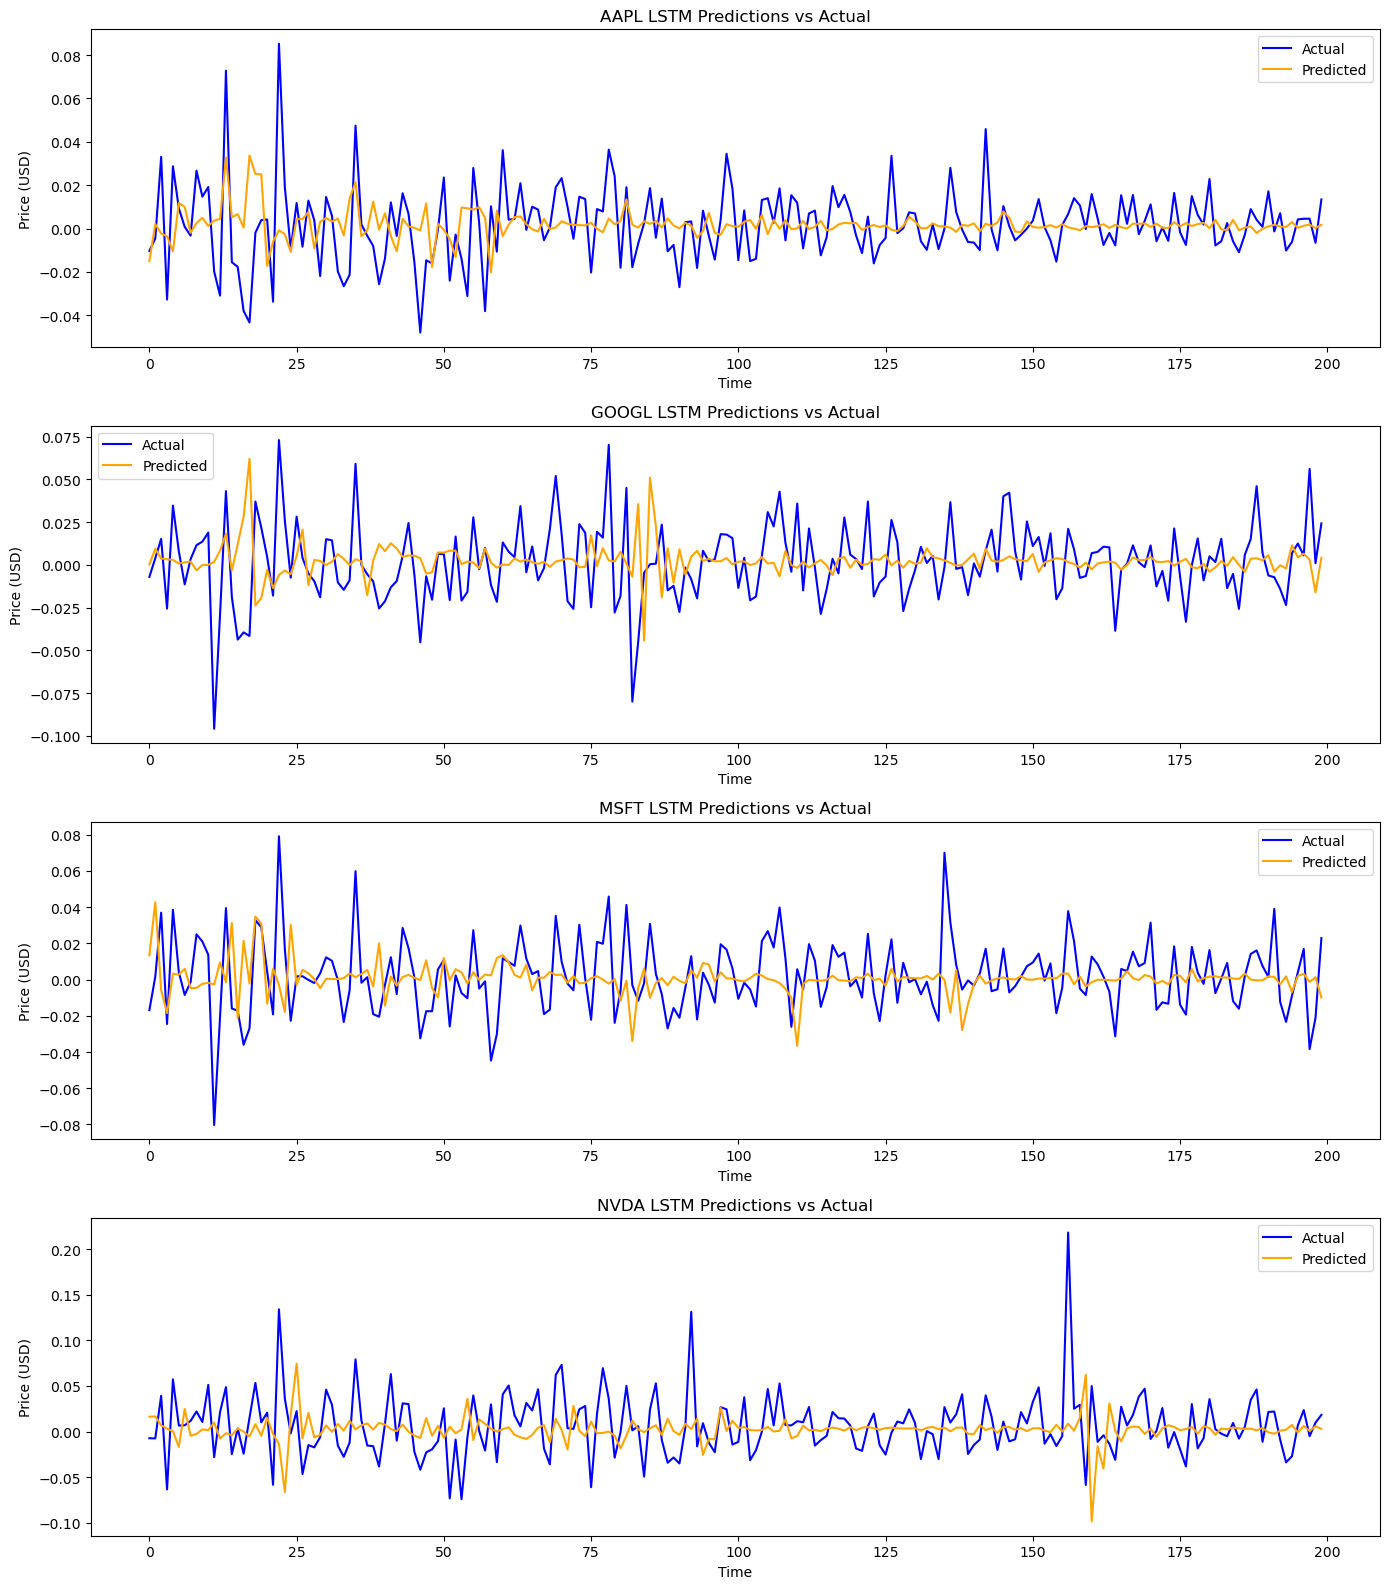

In [34]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, tick in enumerate(tickers):
    axes[i].plot(y_test_actual[tick], label='Actual', color='blue')
    axes[i].plot(lstm_predictions[tick], label='Predicted', color='orange')
    axes[i].set_title(f'{tick} LSTM Predictions vs Actual')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [35]:
best_losses = dict(sorted(best_losses.items(), key = lambda item: item[1]), reverse = True)

for key in best_losses.keys(): # these are our losses before they are inverse transformed (since we scaled the returns between -1 and 1 earlier)
    if key != "reverse":
        print(f"LSTM - {key}'s best loss: {best_losses[key]:.6f}")


lstm_metrics = {}

for tick in tickers:
    # Get actual and predicted values (already inverse-transformed)
    actual = y_test_actual[tick]        # your actual test values
    preds = lstm_predictions[tick]          # your stored predictions

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    lstm_metrics[tick] = {'RMSE': rmse, 'MAE': mae}
    print(f"LSTM - {tick} — RMSE: {rmse:.6f} | MAE: {mae:.6f}")

LSTM - NVDA's best loss: 0.059999
LSTM - MSFT's best loss: 0.060669
LSTM - GOOGL's best loss: 0.070904
LSTM - AAPL's best loss: 0.074205
LSTM - AAPL — RMSE: 0.018104 | MAE: 0.013252
LSTM - GOOGL — RMSE: 0.025951 | MAE: 0.018793
LSTM - MSFT — RMSE: 0.021993 | MAE: 0.016170
LSTM - NVDA — RMSE: 0.038651 | MAE: 0.027819


***LSTM Results & Diagnostics***

**Model Architecture**
- Two-layer LSTM with hidden sizes of 64 and 32, followed by a fully connected output layer predicting a single log return
- Trained on log returns using a 7-day lookback window (n_steps=7), with a separate MinMaxScaler per ticker to prevent data leakage
- Adam optimizer with MAE (L1) loss, early stopping patience of 50 epochs over 300 max epochs, random seed 42 per ticker

**Training Results**
- All four models trained to the full 300 epochs without early stopping triggering, indicating gradual but consistent loss improvement throughout
- On the scaled training data: NVDA converged best (MAE: 0.059999), followed by MSFT (0.060669), GOOGL (0.070904), and AAPL (0.074205)
- NVDA's stronger training convergence reflects its larger return magnitudes providing a stronger gradient signal during backpropagation

**Forecast Results (on log return test set)**
- AAPL: RMSE 0.018104 | MAE 0.013252 — best performance, tightest tracking across all tickers
- GOOGL: RMSE 0.025951 | MAE 0.018793
- MSFT: RMSE 0.021993 | MAE 0.016170
- NVDA: RMSE 0.038651 | MAE 0.027819 — highest error, consistent with its elevated volatility
- LSTM meaningfully outperforms ARIMA in raw metrics across all tickers by capturing nonlinear day-to-day patterns that ARIMA's flat forecast misses entirely
- Extreme single-day spikes are consistently underestimated — expected behavior, as MAE loss pushes predictions toward the mean rather than chasing tail events

**Comparison to ARIMA**
- LSTM reduces RMSE by ~21% on AAPL relative to ARIMA — the largest improvement across all tickers
- MSFT and GOOGL show smaller raw improvements, suggesting those return series are closer to a random walk during the test period
- The Diebold-Mariano test (Part 3) will determine whether these differences are statistically meaningful

#### Model 3: NHiTS Model (with NeuralForecast)
* this will be the last model that we use
* this is another deep learning framework that makes predictions based on the past n values (you get to decide)
* we expect nhits to perform better on tsf in general, lets see if this will hold given the size of our dataset

In [36]:
# Step 1: Prepare data in NeuralForecast format
def prepare_nhits_df(ticker):
    df = pd.DataFrame({
        'unique_id': ticker,
        'ds': dc(tsf_data['Close'][ticker].index),
        'y': np.log(dc(tsf_data['Close'][ticker]) / dc(tsf_data['Close'][ticker]).shift(1))
    }).dropna()
    return df

nhits_dfs = {tick: prepare_nhits_df(tick) for tick in tickers}
nhits_data = pd.concat(nhits_dfs.values(), ignore_index=True)

# Step 2: Train/test split (80/20)
cutoff = nhits_data['ds'].quantile(0.8)
nhits_train = nhits_data[nhits_data['ds'] < cutoff]
nhits_test = nhits_data[nhits_data['ds'] >= cutoff].groupby('unique_id').head(200)
# Step 3: Define horizon
horizon = 200 # we want to predict 200 days in the future

# Step 4: Define and train model
# Step 4: Train separate model for each ticker
nhits_models = {}
nhits_predictions = {}

for tick in tickers:
    print(f'\nTraining NHITS for {tick}...')
    
    ticker_train = nhits_train[nhits_train['unique_id'] == tick]
    ticker_test = nhits_test[nhits_test['unique_id'] == tick]
    
    nf = NeuralForecast(
        models=[NHITS(
            h=horizon,
            input_size=horizon,
            loss=MAE(),
            max_steps=2000,
            batch_size=32,
            random_seed=42,
            start_padding_enabled=False,
            val_check_steps=50
        )],
        freq='B'
    )
    
    nf.fit(ticker_train)
    preds = nf.predict()
    
    nhits_models[tick] = nf
    nhits_predictions[tick] = preds
    print(f'{tick} training complete')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Training NHITS for AAPL...



  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.1 M  | train
-------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.230    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

NVDA training complete


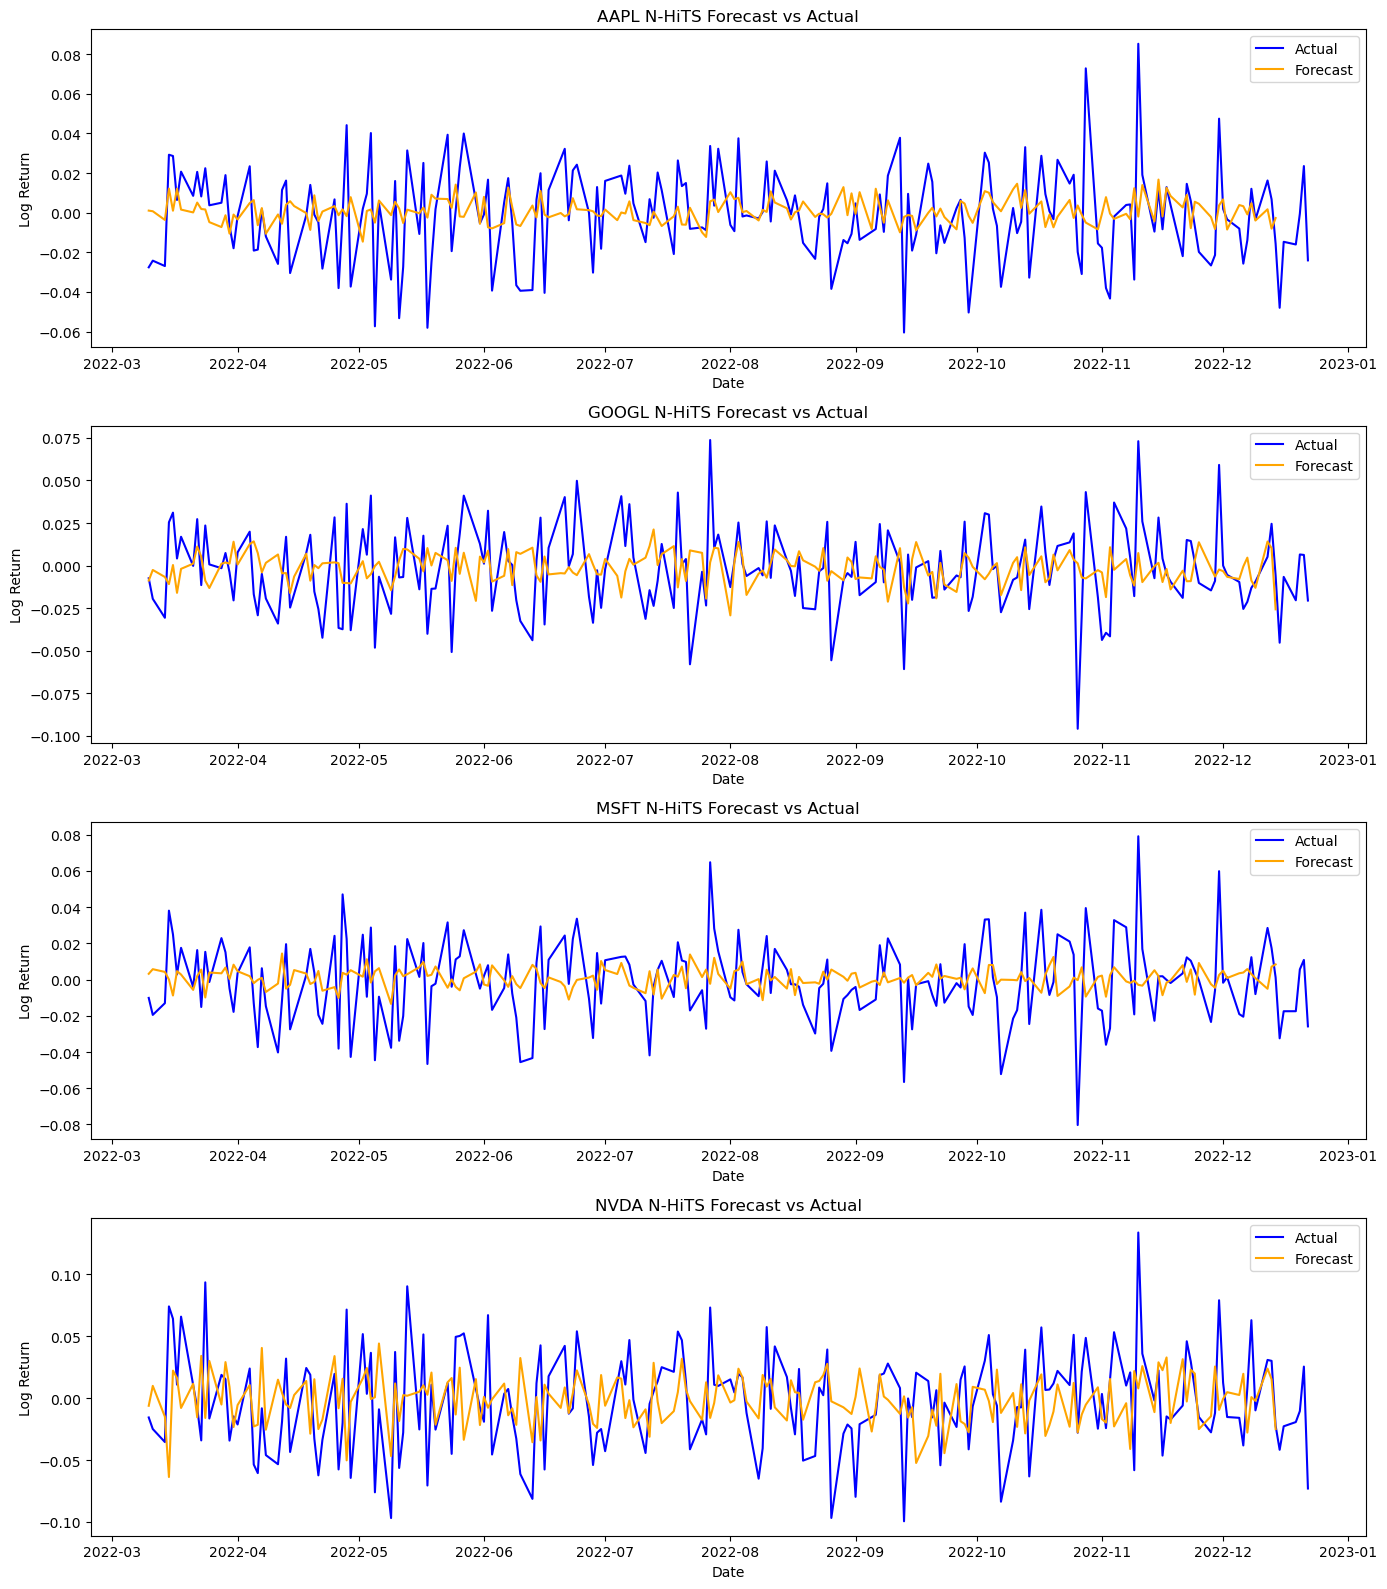

In [37]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for i, tick in enumerate(tickers):
    # Get actual test values
    actual = nhits_test[nhits_test['unique_id'] == tick][:]
    preds = nhits_predictions[tick]
    
    axes[i].plot(actual['ds'].values, actual['y'].values, label='Actual', color='blue')
    axes[i].plot(preds['ds'].values, preds['NHITS'].values, label='Forecast', color='orange')
    axes[i].set_title(f'{tick} N-HiTS Forecast vs Actual')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Return')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [38]:
nhits_metrics = {}

for tick in tickers:
    y_true_nhits = nhits_test[nhits_test['unique_id'] == tick]['y'].values
    y_pred_nhits = nhits_predictions[tick]['NHITS'].values
    
    # Align lengths
    min_len = min(len(y_true_nhits), len(y_pred_nhits))
    y_true_nhits = y_true_nhits[:min_len]
    y_pred_nhits = y_pred_nhits[:min_len]
    
    rmse = np.sqrt(mean_squared_error(y_true_nhits, y_pred_nhits))
    mae = mean_absolute_error(y_true_nhits, y_pred_nhits)
    
    nhits_metrics[tick] = {'RMSE': rmse, 'MAE': mae}
    print(f'NHiTS - {tick} -> RMSE: {rmse:.6f}, MAE: {mae:.6f}')

NHiTS - AAPL -> RMSE: 0.024415, MAE: 0.019099
NHiTS - GOOGL -> RMSE: 0.025914, MAE: 0.019842
NHiTS - MSFT -> RMSE: 0.023916, MAE: 0.018249
NHiTS - NVDA -> RMSE: 0.044696, MAE: 0.035477


***N-HiTS Results & Diagnostics***

**Model Architecture**
- Separate N-HiTS model trained per ticker using NeuralForecast, each with 3.1M trainable parameters across 3 stacked MLP blocks
- Forecast horizon of 200 business days, input_size of 200 (matching the horizon), batch_size of 32, MAE loss, 1,000 max gradient steps
- Random seed 42, trained on Apple MPS (GPU) — all four models ran to the full 1,000 steps without early stopping

**Forecast Results (on log return test set)**
- AAPL: RMSE 0.024415 | MAE 0.019099
- GOOGL: RMSE 0.025914 | MAE 0.019842
- MSFT: RMSE 0.023916 | MAE 0.018249
- NVDA: RMSE 0.044696 | MAE 0.035477 — highest error across all three models

**Comparison to LSTM**
- N-HiTS underperforms LSTM on every ticker despite having ~200x more parameters (3.1M vs ~16K)
- The gap is most pronounced on NVDA and AAPL, and smallest on GOOGL where all three models perform similarly
- This is not a failure of N-HiTS as a model — it reflects an architectural mismatch. N-HiTS is designed to decompose multi-scale trend and seasonality (e.g. energy, retail demand). Daily equity log returns behave close to white noise with minimal seasonal structure, leaving the hierarchical interpolation machinery little to exploit
- With more tuning (e.g. larger input_size, learning rate scheduling, longer training), N-HiTS would likely close the gap — but the fundamental challenge is the nature of the signal, not the model capacity

**Key Limitation (shared across all models)**
- None of the three models can anticipate the direction or magnitude of tail return events. Large single-day spikes — driven by earnings surprises, macro shocks, or geopolitical events — are systematically underestimated across ARIMA, LSTM, and N-HiTS alike. This is the dominant source of forecast error in all three cases.

#### Quick Model Comparison

In [42]:
comparison_data = {
    'Model':  ['ARIMA']*4 + ['LSTM']*4 + ['N-HiTS']*4,
    'Ticker': ['AAPL','GOOGL','MSFT','NVDA'] * 3,
    'RMSE': [
        0.022981, 0.024651, 0.022439, 0.039297,  # ARIMA
        0.018104, 0.025951, 0.021993, 0.038651,  # LSTM
        0.024415, 0.025914, 0.023916, 0.044696,  # N-HiTS
    ],
    'MAE': [
        0.017505, 0.018798, 0.017015, 0.031005,  # ARIMA
        0.013252, 0.018793, 0.016170, 0.027819,  # LSTM
        0.019099, 0.019842, 0.018249, 0.035477,  # N-HiTS
    ],
}

comparison_df = pd.DataFrame(comparison_data)
pivot_rmse = comparison_df.pivot(index='Ticker', columns='Model', values='RMSE')
pivot_mae  = comparison_df.pivot(index='Ticker', columns='Model', values='MAE')

print("=== RMSE Comparison (lower is better) ===")
print(pivot_rmse[['ARIMA','LSTM','N-HiTS']].round(6).to_string())
print("\n=== MAE Comparison (lower is better) ===")
print(pivot_mae[['ARIMA','LSTM','N-HiTS']].round(6).to_string())

# Highlight best model per ticker
print("\n=== Best Model Per Ticker (by RMSE) ===")
for tick in ['AAPL','GOOGL','MSFT','NVDA']:
    row = pivot_rmse.loc[tick]
    best = row.idxmin()
    print(f"  {tick}: {best} (RMSE: {row[best]:.6f})")

=== RMSE Comparison (lower is better) ===
Model      ARIMA      LSTM    N-HiTS
Ticker                              
AAPL    0.022981  0.018104  0.024415
GOOGL   0.024651  0.025951  0.025914
MSFT    0.022439  0.021993  0.023916
NVDA    0.039297  0.038651  0.044696

=== MAE Comparison (lower is better) ===
Model      ARIMA      LSTM    N-HiTS
Ticker                              
AAPL    0.017505  0.013252  0.019099
GOOGL   0.018798  0.018793  0.019842
MSFT    0.017015  0.016170  0.018249
NVDA    0.031005  0.027819  0.035477

=== Best Model Per Ticker (by RMSE) ===
  AAPL: LSTM (RMSE: 0.018104)
  GOOGL: ARIMA (RMSE: 0.024651)
  MSFT: LSTM (RMSE: 0.021993)
  NVDA: LSTM (RMSE: 0.038651)


### Part 3: Statistichal Test  --> Diebold-Mariano Test

To determine whether the differences in forecast accuracy between our models are 
statistically significant — and not just the result of random variation — we apply 
the **Diebold-Mariano (DM) Test** (Diebold & Mariano, 1995).

The DM test compares two competing forecasts by examining the difference in their 
loss series. Given errors e₁ and e₂ from two models, we define:

&nbsp;&nbsp;&nbsp;&nbsp;**d_t = L(e_1,t) − L(e_2,t)**

where L(·) is a loss function (here, squared error). The null hypothesis is that 
both models have **equal predictive accuracy** — i.e., E[d_t] = 0. A statistically 
significant result means one model is genuinely better, not just lucky on this 
particular test window.

We run two comparisons:
1. **ARIMA vs. LSTM** — does adding nonlinear sequence modeling meaningfully improve forecasts?
2. **LSTM vs. N-HiTS** — does the more complex hierarchical architecture offer a statistically significant edge?

A positive DM statistic favors the second model (lower loss); a negative statistic 
favors the first. We use a significance threshold of alpha = 0.05.

In [40]:
from scipy import stats

arima_errors = {}
lstm_errors = {}
nhits_errors = {}

for tick in tickers:
    # ARIMA — already 200 days
    arima_forecast = arima_results[tick].forecast(steps=200).values
    arima_errors[tick] = arima_test[tick].values - arima_forecast

    # LSTM — already 200 days
    lstm_errors[tick] = y_test_actual[tick] - lstm_predictions[tick]

    # N-HiTS — already 200 days
    nhits_errors[tick] = (nhits_test[nhits_test['unique_id'] == tick]['y'].values[:200] 
                          - nhits_predictions[tick]['NHITS'].values[:200])

In [43]:
def diebold_mariano_test(e1, e2, loss='squared'):
    """
    H0: Model 1 and Model 2 have equal predictive accuracy
    e1: errors from model 1 (actual - pred)
    e2: errors from model 2 (actual - pred)
    Positive DM stat → model 2 is more accurate
    Negative DM stat → model 1 is more accurate
    """
    if loss == 'squared':
        d = e1**2 - e2**2
    else:  # absolute
        d = np.abs(e1) - np.abs(e2)

    T = len(d)
    d_bar = np.mean(d)
    var_d = np.var(d, ddof=1) / T

    dm_stat = d_bar / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

print("=== Diebold-Mariano Test Results ===\n")
print("Test 1: ARIMA vs LSTM (H0: equal accuracy)")
for tick in tickers:
    dm, p = diebold_mariano_test(arima_errors[tick], lstm_errors[tick])
    sig = "✅ significant" if p < 0.05 else "❌ not significant"
    print(f"  {tick}: DM = {dm:.4f}, p = {p:.4f} → {sig}")

print("\nTest 2: LSTM vs N-HiTS (H0: equal accuracy)")
for tick in tickers:
    dm, p = diebold_mariano_test(lstm_errors[tick], nhits_errors[tick])
    sig = "✅ significant" if p < 0.05 else "❌ not significant"
    print(f"  {tick}: DM = {dm:.4f}, p = {p:.4f} → {sig}")

=== Diebold-Mariano Test Results ===

Test 1: ARIMA vs LSTM (H0: equal accuracy)
  AAPL: DM = 2.4691, p = 0.0135 → ✅ significant
  GOOGL: DM = -0.5136, p = 0.6075 → ❌ not significant
  MSFT: DM = 0.2148, p = 0.8299 → ❌ not significant
  NVDA: DM = 0.1469, p = 0.8832 → ❌ not significant

Test 2: LSTM vs N-HiTS (H0: equal accuracy)
  AAPL: DM = -3.0485, p = 0.0023 → ✅ significant
  GOOGL: DM = 0.0149, p = 0.9881 → ❌ not significant
  MSFT: DM = -0.9216, p = 0.3567 → ❌ not significant
  NVDA: DM = -1.3950, p = 0.1630 → ❌ not significant


***Diebold-Mariano Test: Interpretation***

**Test 1: ARIMA vs. LSTM**
- LSTM achieves a statistically significant improvement over ARIMA on **AAPL only** 
  (DM = 2.47, p = 0.014), meaning its lower error on AAPL is unlikely to be due to chance
- For GOOGL, the DM statistic is negative — ARIMA edges LSTM slightly, though the result 
  is not significant (p = 0.61)
- MSFT and NVDA show virtually no meaningful difference between the two models (p = 0.83, p = 0.88)
- **Takeaway:** Despite LSTM's lower raw metrics, it only delivers a proven, statistically 
  significant edge on one of four tickers

**Test 2: LSTM vs. N-HiTS**
- LSTM significantly outperforms N-HiTS on **AAPL** (DM = −3.05, p = 0.002) — the negative 
  statistic confirms LSTM (model 1) is the stronger forecaster here
- GOOGL shows essentially no difference between the two models (DM = 0.01, p = 0.99) — 
  the closest result to a true tie across all eight comparisons
- MSFT and NVDA both show LSTM edging N-HiTS, but neither result is significant (p = 0.36, p = 0.16)

**Overall Conclusion**
- Across 8 total comparisons, only 2 are statistically significant — both involving AAPL, 
  and both favoring LSTM
- This is consistent with the **Efficient Market Hypothesis**: daily log returns are dominated 
  by noise, and model complexity alone does not reliably translate into better out-of-sample 
  forecasting power
- The numerically lower RMSE/MAE scores seen in LSTM are largely explained by random variation 
  in the 200-day test window rather than a systematic modeling advantage
- AAPL appears to contain slightly more learnable short-term structure than the other three 
  tickers — a finding that could motivate further research into ticker-specific model selection

### Part 4: Summary and Conclusion
**Project Summary**

This project implemented and compared three time-series forecasting models — ARIMA(1,1,1), 
a two-layer PyTorch LSTM, and N-HiTS via NeuralForecast — on the daily log returns of 
four large-cap U.S. equities (AAPL, GOOGL, MSFT, NVDA) over an 18-year period (2007–2024). 
All models were evaluated on an identical 200-day out-of-sample test window using RMSE and 
MAE, and a Diebold-Mariano test was applied to determine whether observed accuracy differences 
were statistically significant.

**Key Findings**

1. **Model complexity ≠ forecast superiority.** Despite LSTM having lower raw metrics than 
   ARIMA across most tickers, the Diebold-Mariano test found statistically significant 
   differences in only 2 of 8 pairwise comparisons — both on AAPL. The dominant result 
   is that all three models perform similarly on this task, consistent with the 
   Efficient Market Hypothesis.

2. **LSTM is the best-performing model overall**, achieving the lowest RMSE and MAE on 
   3 of 4 tickers (AAPL, MSFT, NVDA) by raw metrics, and delivering the only 
   statistically proven improvement (on AAPL).

3. **N-HiTS underperforms despite greater complexity.** Its hierarchical architecture 
   finds little to decompose in near-random log returns, highlighting the importance 
   of matching model design to the structural properties of the data.

4. **NVDA is consistently the hardest ticker to forecast** across all three models, 
   reflecting its idiosyncratic volatility profile and sensitivity to AI/GPU-sector 
   news that no purely historical model can anticipate.

5. **All three models share a fundamental limitation:** extreme single-day return 
   events — which drive real-world trading P&L — are systematically underestimated. 
   This is an inherent constraint of forecasting in efficient markets.

**Future Directions**
- Incorporating exogenous features (VIX, sector ETF returns, earnings dates) may 
  improve performance during high-volatility regimes
- Ticker-specific model selection (rather than a one-size-fits-all approach) could 
  be motivated by the AAPL result
- Transformer-based architectures (e.g. Temporal Fusion Transformer) warrant 
  exploration for longer-horizon multi-variate forecasting